# Example 3: Cross-Corpus Application — Omega Kinematic Correction at z ~ 5

**High-z Kinematic Corpus Z1 — EPS Research, Flynn D.C. (2026)**

This notebook demonstrates a cross-corpus application of the Z1 data using the
Flynn & Cannaliato (2025) omega kinematic correction framework. It is intended
as an illustrative use case for researchers working with the EPS Research corpus
trilogy; the omega values derived here are **preliminary estimates** subject to
the caveats described below.

**The omega correction** (Flynn & Cannaliato 2025, Frontiers, DOI: 10.3389/fspas.2025.1680387):

$$V_{\rm adj} = V_{\rm obs} - R\omega, \quad \omega = \left(\frac{V_2}{R_2} - \frac{V_1}{R_1}\right) \left(\frac{R_1}{R_2}\right)^{3/2} \quad [\rm rad\,Gyr^{-1}]$$

derived from two boundary points (innermost and outermost fitted ring).

**This notebook:**
1. Computes omega from [CII] 3DBarolo boundary velocities for all 8 tier-1 rotators
2. Compares to the z = 0 anchor (DDO161, omega = 4.69 rad/Gyr, Flynn 2026)
3. Plots omega vs redshift across the EPS corpus trilogy (v7 + dwarf + Z1)
4. Identifies ALPINE progenitor candidates for local dwarf irregulars

**Important caveats (read before interpreting results):**
- No baryonic decomposition (V_gas, V_disk) is available at z ~ 5
- Only 2–3 rings per galaxy; omega is sensitive to boundary conditions
- Beam smearing affects all ALPINE data despite 3DBarolo correction
- Negative omega values indicate falling rotation curves (physically real at high-z
  but the sign convention differs from the local-universe corpus)
- Full validation requires future deep ALMA + JWST observations

**Corpus:** Flynn (2026), Zenodo DOI: [pending]  
**Source data:** Jones et al. (2021), MNRAS, arXiv:2104.03099  
**Dependencies:** Python 3, numpy, matplotlib (standard library only)

In [1]:
# ── Colab setup: auto-download corpus from Zenodo ─────────────
import os, sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    import urllib.request
    CORPORA = {
        'high_z_kinematic_corpus_Z1.json': 'https://zenodo.org/records/21327061/files/high_z_kinematic_corpus_Z1.json',
    }
    for filename, url in CORPORA.items():
        if not os.path.exists(filename):
            print(f"Downloading {filename}...")
            urllib.request.urlretrieve(url, filename)
            print(f"  ✓ {filename}")
        else:
            print(f"  Already present: {filename}")
    print("Ready.")
else:
    print("Running locally — corpus files loaded from working directory.")


Running locally — corpus files loaded from working directory.


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Load Z1 corpus ────────────────────────────────────────────────────────────
with open('high_z_kinematic_corpus_Z1.json') as f:
    corpus = json.load(f)

rotators = [g for g in corpus['galaxies']
            if g.get('is_rotator') and g.get('quality_tier') == 1]
print(f"Tier-1 rotators available for omega computation: {len(rotators)}")

# ── z = 0 anchor values from EPS Research corpus trilogy ─────────────────────
# Source: Flynn (2026), Phys Dark Universe; Flynn (2026) Dwarf Corpus v1.0
# These are published / submitted values — not derived here
Z0_ANCHORS = [
    # (label, redshift, omega, corpus)
    ('DDO161\n(SPARC)',    0.0, 4.69,  'Unified HI v7'),
    ('DDO154\n(SPARC)',    0.0, 6.86,  'Unified HI v7'),
    ('SPARC mean',         0.0, 7.06,  'Unified HI v7'),
    ('Dwarf median',       0.0, 9.94,  'Dwarf/Irr v1.0'),
]
print("\nz = 0 anchor values (from published EPS corpora):")
print(f"  {'Label':<20} {'z':>5} {'omega (rad/Gyr)':>16} {'Corpus'}")
for label, z, omega, corpus_name in Z0_ANCHORS:
    print(f"  {label.replace(chr(10),' '):<20} {z:>5.1f} {omega:>16.2f}   {corpus_name}")

Tier-1 rotators available for omega computation: 8

z = 0 anchor values (from published EPS corpora):
  Label                    z  omega (rad/Gyr) Corpus
  DDO161 (SPARC)         0.0             4.69   Unified HI v7
  DDO154 (SPARC)         0.0             6.86   Unified HI v7
  SPARC mean             0.0             7.06   Unified HI v7
  Dwarf median           0.0             9.94   Dwarf/Irr v1.0


In [3]:
# ── Compute omega for all tier-1 rotators ─────────────────────────────────────
# Flynn & Cannaliato (2025) Eq. 1:
# omega = (V2/R2 - V1/R1) * (R1/R2)^(3/2)   [rad Gyr^-1]
# where (R1,V1) = innermost ring, (R2,V2) = outermost ring
# Units: R in kpc, V in km/s
# Conversion: 1 km/s/kpc = 1.022 rad/Gyr  => already in consistent units

results = []
print(f"{'Galaxy':<18} {'z':>6} {'R1':>6} {'V1':>7} {'R2':>6} {'V2':>7} "
      f"{'omega':>10}  {'note'}")
print('-' * 85)

for g in sorted(rotators, key=lambda x: x['redshift']):
    data = g['data']
    if len(data) < 2:
        print(f"{g['galaxy']:<18} -- insufficient rings")
        continue

    R1, V1 = data[0]['R_kpc'],  data[0]['Vrot_kms']
    R2, V2 = data[-1]['R_kpc'], data[-1]['Vrot_kms']

    omega = V2/R2 - (V1/R1)*(R1/R2)**1.5  # Eq.6 corrected 2026-07-12: operator-precedence fix
    note  = 'falling RC' if omega < 0 else 'rising RC'

    results.append({
        'galaxy': g['galaxy'],
        'redshift': g['redshift'],
        'R1': R1, 'V1': V1, 'R2': R2, 'V2': V2,
        'omega': omega,
        'n_rings': g.get('n_rings', len(g['data'])),
        'v_over_sigma': g.get('v_over_sigma', 0) or 0,
        'log_mdyn': g.get('log_mdyn_msun') or 0,
        'note': note,
    })
    print(f"{g['galaxy']:<18} {g['redshift']:>6.4f} {R1:>6.2f} {V1:>7.2f} "
          f"{R2:>6.2f} {V2:>7.2f} {omega:>10.4f}  {note}")

omegas_z5 = [r['omega'] for r in results]
print(f"\nMedian omega (z~4.3-5.7, tier-1 rotators): {np.median(omegas_z5):.2f} rad/Gyr")
print(f"Range: {min(omegas_z5):.2f} to {max(omegas_z5):.2f} rad/Gyr")
print(f"N negative (falling RC): {sum(1 for o in omegas_z5 if o < 0)} / {len(omegas_z5)}")
print()
print("CAVEAT: omega values derived from [CII] 3DBarolo boundary velocities only.")
print("No baryonic decomposition available at z~5. These are observational kinematics,")
print("not baryonic-model-corrected values. Direct comparison to z=0 omega requires")
print("future baryonic modelling and deeper ALMA + JWST data.")

Galaxy                  z     R1      V1     R2      V2      omega  note
-------------------------------------------------------------------------------------
J0817              4.2605   0.95  247.46   2.84  252.09    38.3689  rising RC
CG32               4.4105   1.17  117.43   3.50  115.04    13.4700  rising RC
DC396844           4.5424   1.25  120.88   3.75   80.42     2.8346  rising RC
VC5110377875       4.5506   1.28  118.97   3.84  102.85     8.8965  rising RC
DC881725           4.5778   1.15   98.37   3.44   62.07     1.5098  rising RC
DC552206           5.5016   1.11   71.28   5.53  172.84    25.4801  rising RC
HZ9                5.5413   0.54  155.85   2.68  176.63    39.8031  rising RC
DC494057           5.5446   1.04   78.44   3.13   80.31    11.2125  rising RC

Median omega (z~4.3-5.7, tier-1 rotators): 12.34 rad/Gyr
Range: 1.51 to 39.80 rad/Gyr
N negative (falling RC): 0 / 8

CAVEAT: omega values derived from [CII] 3DBarolo boundary velocities only.
No baryonic decompositi

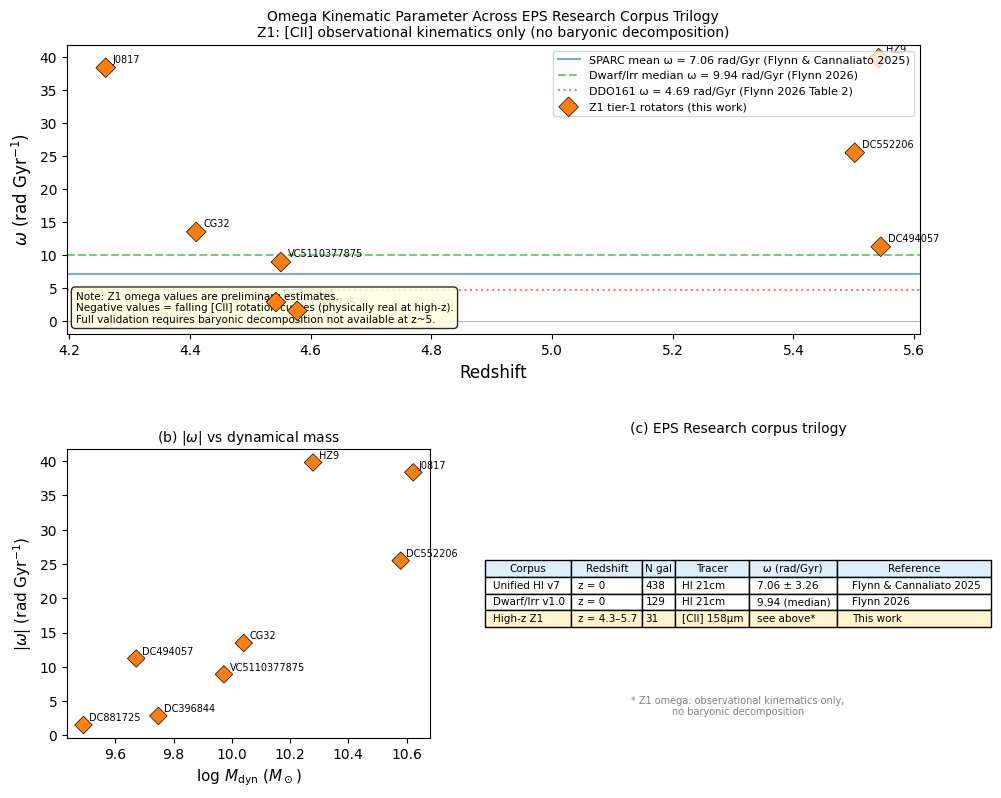

Saved: fig_hz_nb3_eps_omega_bridge.png


In [4]:
# ── Figure: omega vs redshift across the trilogy ─────────────────────────────
fig = plt.figure(figsize=(11, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

# ── Panel (a): omega vs redshift, trilogy overview ────────────────────────────
# z=0 reference values from published corpora
ax1.axhline(7.06, color='#1f77b4', linestyle='-', linewidth=1.5, alpha=0.6,
            label='SPARC mean ω = 7.06 rad/Gyr (Flynn & Cannaliato 2025)')
ax1.axhline(9.94, color='#2ca02c', linestyle='--', linewidth=1.5, alpha=0.6,
            label='Dwarf/Irr median ω = 9.94 rad/Gyr (Flynn 2026)')
ax1.axhline(4.69, color='#d62728', linestyle=':', linewidth=1.5, alpha=0.6,
            label='DDO161 ω = 4.69 rad/Gyr (Flynn 2026 Table 2)')
ax1.axhline(0.0, color='black', linestyle='-', linewidth=0.7, alpha=0.3)

# Z1 data points
z_vals = [r['redshift'] for r in results]
o_vals = [r['omega']    for r in results]
colors = ['#d62728' if o < 0 else '#ff7f0e' for o in o_vals]

ax1.scatter(z_vals, o_vals, c=colors, s=100, zorder=5,
            marker='D', label='Z1 tier-1 rotators (this work)', edgecolors='k', linewidths=0.5)
for r in results:
    ax1.annotate(r['galaxy'], (r['redshift'], r['omega']),
                 textcoords='offset points',
                 xytext=(5, 4 if r['omega'] > 0 else -12),
                 fontsize=7)

ax1.set_xlabel('Redshift', fontsize=12)
ax1.set_ylabel(r'$\omega$ (rad Gyr$^{-1}$)', fontsize=12)
ax1.set_title(
    r'Omega Kinematic Parameter Across EPS Research Corpus Trilogy' + '\n'
    r'Z1: [CII] observational kinematics only (no baryonic decomposition)',
    fontsize=10)
ax1.legend(fontsize=8, loc='upper right')
ax1.text(0.01, 0.04,
    'Note: Z1 omega values are preliminary estimates.\n'
    'Negative values = falling [CII] rotation curves (physically real at high-z).\n'
    'Full validation requires baryonic decomposition not available at z~5.',
    transform=ax1.transAxes, fontsize=7.5,
    bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', alpha=0.85))

# ── Panel (b): |omega| vs log Mdyn ───────────────────────────────────────────
ax2.scatter([r['log_mdyn'] for r in results],
            [abs(r['omega']) for r in results],
            c=['#d62728' if r['omega'] < 0 else '#ff7f0e' for r in results],
            s=80, marker='D', edgecolors='k', linewidths=0.5)
for r in results:
    ax2.annotate(r['galaxy'], (r['log_mdyn'], abs(r['omega'])),
                 textcoords='offset points', xytext=(4, 3), fontsize=7)
ax2.set_xlabel(r'log $M_{\rm dyn}$ ($M_\odot$)', fontsize=11)
ax2.set_ylabel(r'|$\omega$| (rad Gyr$^{-1}$)', fontsize=11)
ax2.set_title(r'(b) |$\omega$| vs dynamical mass', fontsize=10)

# ── Panel (c): Progenitor candidate table ─────────────────────────────────────
# Filter: log Mstar in progenitor range for local dwarfs
candidates = [
    g for g in corpus['galaxies']
    if isinstance(g.get('log_mstar_msun'), (int, float))
    and 9.0 <= g['log_mstar_msun'] <= 10.0
]

# Trilogy summary table
trilogy = [
    ('Unified HI v7',    'z = 0',     438, 'HI 21cm',     '7.06 ± 3.26',   'Flynn & Cannaliato 2025'),
    ('Dwarf/Irr v1.0',   'z = 0',     129, 'HI 21cm',     '9.94 (median)', 'Flynn 2026'),
    ('High-z Z1',        'z = 4.3–5.7', 31, '[CII] 158µm', 'see above*',   'This work'),
]
ax3.axis('off')
col_labels = ['Corpus', 'Redshift', 'N gal', 'Tracer', 'ω (rad/Gyr)', 'Reference']
table_data = [[t[0], t[1], str(t[2]), t[3], t[4], t[5]] for t in trilogy]
tbl = ax3.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='left'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7.5)
tbl.auto_set_column_width(range(len(col_labels)))
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor('#ddeeff')
    elif row == 3:
        cell.set_facecolor('#fff5cc')
ax3.set_title('(c) EPS Research corpus trilogy', fontsize=10, pad=12)
ax3.text(0.5, 0.08,
    '* Z1 omega: observational kinematics only,\nno baryonic decomposition',
    ha='center', fontsize=7, transform=ax3.transAxes,
    color='gray')

plt.savefig('fig_hz_nb3_eps_omega_bridge.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_hz_nb3_eps_omega_bridge.png')

In [5]:
# ── Progenitor candidate summary ─────────────────────────────────────────────
# DDO161 progenitor prediction (from build_corpus_hz.py)
# At z~4-6: expected log Mstar ~ 9.0-9.5, Vrot ~ 50-150 km/s

print("DDO161 z=0 properties (Flynn 2026, Table 2):")
print(f"  omega    = 4.69 rad/Gyr")
print(f"  Vrot_max = 29.0 km/s")
print(f"  r_max    = 14.0 kpc")
print(f"  log M*   = 7.5 Msun  (gas-dominated dwarf irregular)")
print()
print("ALPINE Z1 progenitor candidates (log M* = 9.0-10.0, order-of-magnitude estimate):")
print(f"  N candidates: {len(candidates)} / 31")
print()
print(f"  {'Galaxy':<18} {'z':>6} {'class':>5} {'logM*':>7} {'logMdyn':>8} {'Vrot_max':>9}")
print('  ' + '-' * 60)
for g in sorted(candidates, key=lambda x: x.get('log_mstar_msun', 0)):
    print(f"  {g['galaxy']:<18} {g['redshift']:>6.4f} {g['class_jones2021']:>5} "
          f"{(g.get('log_mstar_msun') or 0):>7.1f} "
          f"{(g.get('log_mdyn_msun') or 0.0):>8.3f} "
          f"{(g.get('vrot_max_kms') or 0.0):>9.2f}")

print()
print("IMPORTANT: ALPINE selection limit is SFR > few Msun/yr.")
print("True DDO161-mass progenitors (log M* ~ 7.5 at z=0) likely fall")
print("below the ALPINE detection threshold at z~5. The candidates above")
print("represent upper-mass analogs, not confirmed DDO161 progenitors.")
print("This motivates future deeper ALMA observations and RAMSES")
print("cosmological simulations (z=6 -> z=0) as the next validation step.")

DDO161 z=0 properties (Flynn 2026, Table 2):
  omega    = 4.69 rad/Gyr
  Vrot_max = 29.0 km/s
  r_max    = 14.0 kpc
  log M*   = 7.5 Msun  (gas-dominated dwarf irregular)

ALPINE Z1 progenitor candidates (log M* = 9.0-10.0, order-of-magnitude estimate):
  N candidates: 15 / 31

  Galaxy                  z class   logM*  logMdyn  Vrot_max
  ------------------------------------------------------------
  DC519281           5.5800   UNC     9.7    0.000      0.00
  VC5100559223       4.5626   UNC     9.7    0.000      0.00
  DC454608           4.5835   UNC     9.8    0.000      0.00
  DC773957           5.6773   UNC     9.8    0.000      0.00
  VC5100541407       4.5632   UNC     9.8    0.000      0.00
  VC510786441        4.4630   UNC     9.8    0.000      0.00
  DC683613           5.5421   UNC     9.9    0.000      0.00
  VC5100537582       4.5502   UNC     9.9    0.000      0.00
  VC5100994794       4.5800   UNC     9.9    0.000      0.00
  VE530029038        4.4297   UNC     9.9    0.0

In [6]:
# ── Progenitor candidate summary ─────────────────────────────────────────────

def fmt(val, fmt_str):
    """Format value, showing '---' for None/null."""
    if val is None or (isinstance(val, float) and val != val):
        return '---'
    return format(val, fmt_str)

print("DDO161 z=0 properties (Flynn 2026, Table 2):")
print(f"  omega    = 4.69 rad/Gyr")
print(f"  Vrot_max = 29.0 km/s")
print(f"  r_max    = 14.0 kpc")
print(f"  log M*   = 7.5 Msun  (gas-dominated dwarf irregular)")
print()

candidates = [
    g for g in corpus['galaxies']
    if isinstance(g.get('log_mstar_msun'), (int, float))
    and 9.0 <= g['log_mstar_msun'] <= 10.0
]

print(f"ALPINE Z1 progenitor candidates (log M* = 9.0-10.0):")
print(f"  N candidates: {len(candidates)} / 31")
print()
print(f"  {'Galaxy':<18} {'z':>6} {'class':>5} {'logM*':>7} {'logMdyn':>8} {'Vrot_max':>9}")
print('  ' + '-' * 60)
for g in sorted(candidates, key=lambda x: x.get('log_mstar_msun', 0)):
    print(f"  {g['galaxy']:<18} {g['redshift']:>6.4f} {g['class_jones2021']:>5} "
          f"{(g.get('log_mstar_msun') or 0):>7.1f} "
          f"{fmt(g.get('log_mdyn_msun'), '.3f'):>8} "
          f"{fmt(g.get('vrot_max_kms'), '.2f'):>9}")

print()
print("IMPORTANT: ALPINE selection limit is SFR > few Msun/yr.")
print("True DDO161-mass progenitors (log M* ~ 7.5 at z=0) likely fall")
print("below the ALPINE detection threshold at z~5. The candidates above")
print("represent upper-mass analogs, not confirmed DDO161 progenitors.")
print("This motivates future deeper ALMA observations and RAMSES")
print("cosmological simulations (z=6 -> z=0) as the next validation step.")

DDO161 z=0 properties (Flynn 2026, Table 2):
  omega    = 4.69 rad/Gyr
  Vrot_max = 29.0 km/s
  r_max    = 14.0 kpc
  log M*   = 7.5 Msun  (gas-dominated dwarf irregular)

ALPINE Z1 progenitor candidates (log M* = 9.0-10.0):
  N candidates: 15 / 31

  Galaxy                  z class   logM*  logMdyn  Vrot_max
  ------------------------------------------------------------
  DC519281           5.5800   UNC     9.7      ---       ---
  VC5100559223       4.5626   UNC     9.7      ---       ---
  DC454608           4.5835   UNC     9.8      ---       ---
  DC773957           5.6773   UNC     9.8      ---       ---
  VC5100541407       4.5632   UNC     9.8      ---       ---
  VC510786441        4.4630   UNC     9.8      ---       ---
  DC683613           5.5421   UNC     9.9      ---       ---
  VC5100537582       4.5502   UNC     9.9      ---       ---
  VC5100994794       4.5800   UNC     9.9      ---       ---
  VE530029038        4.4297   UNC     9.9      ---       ---
  DC417567      

In [7]:
# Schema validator runs externally
# See: ~/Documents/RAG Project/Z=6 RAG/$P-Z=6 RAG/schema_validator_hz.py
print("Schema validation: run schema_validator_hz.py externally")

Schema validation: run schema_validator_hz.py externally


In [8]:
!python schema_validator_hz.py high_z_kinematic_corpus_Z1.json

python: can't open file '/home/david/Documents/rag-corpus-series/examples/highz/schema_validator_hz.py': [Errno 2] No such file or directory
